<div align = "center">

Assignment 2 : Image Filtering, Feature Extraction, and CNN Architecture

Computer Vision

Trishita Patra

</div>

### Requirements

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files

In [2]:
uploaded = files.upload()

Saving moon.jpg to moon.jpg


### Q1. Spatial filters on `moon.jpg`

#### a-b : Box and Gaussian Filter

In [3]:
img = cv2.imread('moon.jpg', cv2.IMREAD_GRAYSCALE)

# (a) Box filter 9x9
box = cv2.blur(img, (9, 9))

# (b) Gaussian filter (kernel 9x9, sigma auto)
gauss = cv2.GaussianBlur(img, (9, 9), 0)

#### c : Laplacian Filter

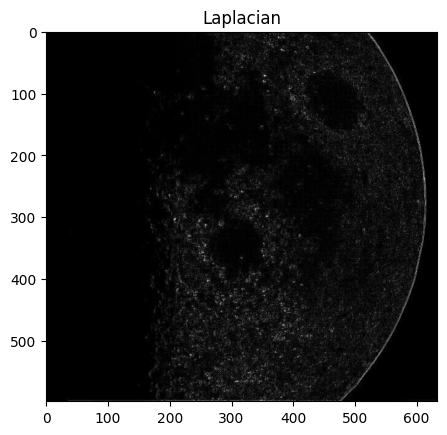

In [4]:
laplacian = cv2.Laplacian(img, cv2.CV_64F, ksize=1)
laplacian_display = cv2.convertScaleAbs(laplacian)

# Visually inspect laplacian_display first
plt.imshow(laplacian_display, cmap='gray'); plt.title("Laplacian"); plt.show()

**The addWeighted formula**

$$ output(x,y) = α ⋅ img(x,y) + β ⋅ laplacian(x,y) + γ$$

- `beta (β)`: controls edge strength (sharpening intensity)
- `gamma (γ):` controls overall brightness offset
- Usually `alpha (α)` is set to 1 to preserve the original image; lowering it reduces the base image contribution.
- `gamma` is just a constant added to every pixel (brightness shift).
- Here we want to enhance edges (for sharpening), not change overall brightness, so we keep `α` and `γ` fixed, and try to find the appropriate `β`.
  - `beta < 0` → subtract Laplacian → sharpening (desired)
  - `beta > 0` → add Laplacian → smoothing / edge suppression (opposite effect)

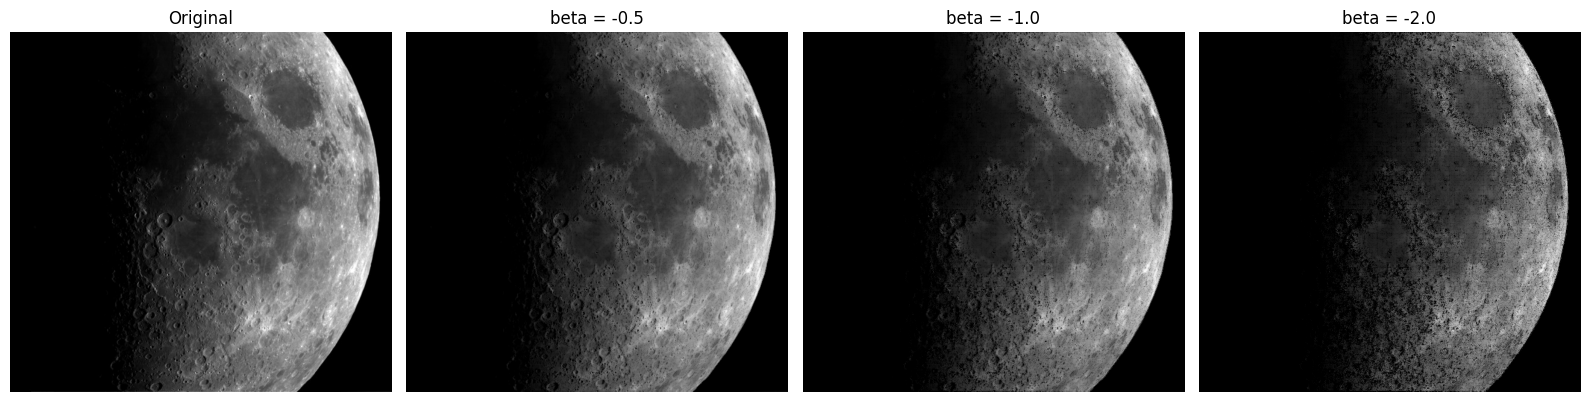

In [5]:
betas = [-0.5, -1.0, -2.0]

plt.figure(figsize=(16, 4))

# Show original image
plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

# Show sharpened images
for i, beta in enumerate(betas):
    sharpened = cv2.addWeighted(img, 1.0, laplacian_display, beta, 0)

    plt.subplot(1, 4, i + 2)
    plt.imshow(sharpened, cmap='gray')
    plt.title(f"beta = {beta}")
    plt.axis('off')

plt.tight_layout()
plt.show()

- beta = -0.5: mild sharpening, preserves natural look but edges are slightly weak  
- beta = -1.0: balanced sharpening, good edge enhancement without excessive noise (best choice)  
- beta = -2.0: strong sharpening, over-enhances edges and introduces visible noise/artifacts (too many dark spots.)

##### Scope of Exploration
Quantitative methods to determine which `beta` is apropriate.

#### d : Sobel Filter

In [6]:
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.convertScaleAbs(np.sqrt(sobelx**2 + sobely**2))

#### Comparison between filters

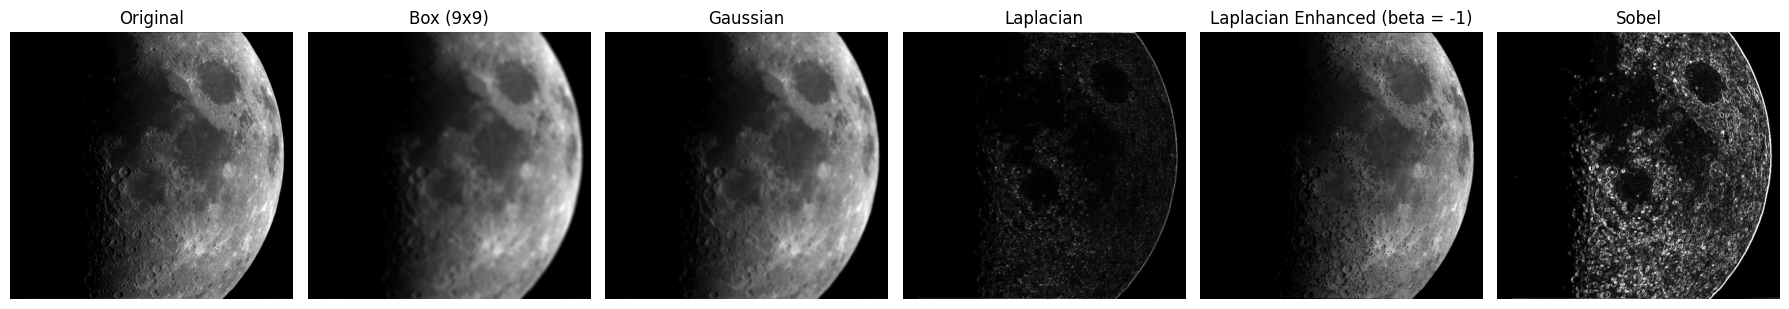

In [7]:
sharpened = cv2.addWeighted(img, 1.0, laplacian_display,-1, 0)

titles = ['Original', 'Box (9x9)', 'Gaussian', 'Laplacian', 'Laplacian Enhanced (beta = -1)', 'Sobel']
images = [img, box, gauss, laplacian_display, sharpened, sobel_mag]

plt.figure(figsize=(18, 6))
for i, (t, im) in enumerate(zip(titles, images)):
    plt.subplot(1, 6, i+1)
    plt.imshow(im, cmap='gray')
    plt.title(t); plt.axis('off')
plt.tight_layout()
plt.savefig('q1_filters.png', dpi=150)
plt.show()

#### Observations

- Box filter: Uniformly blurs the image, reducing noise but also blurring edges/craters — all neighbors weighted equally.

- Gaussian filter: Smoother blur than box; preserves edges slightly better because weights decrease with distance from center.

- Laplacian filter: Highlights regions of rapid intensity change (edges/crater rims). Subtracting from original sharpens/enhances those edges.

- Sobel filter: Detects directional gradients; the magnitude image clearly shows crater boundaries and surface texture edges.

### Q2. Viola-Jones Algorithm

#### a :  Main steps and features

The Viola-Jones (VJ) face detection algorithm has four key components :

- Haar-like rectangle features — Simple rectangular intensity-difference features (two-rectangle horizontal/vertical, three-rectangle, and four-rectangle), computed efficiently via the integral image.

- Integral image — Allows any rectangular sum to be computed in O(1) time using only 4 array lookups, regardless of rectangle size.

- AdaBoost learning — A cascade of weak classifiers (each based on a single Haar feature and threshold) is combined into a strong classifier. Only the most discriminative features are selected.

- Attentional cascade — A sequence of increasingly complex classifiers; sub-windows rejected early avoid expensive computation. This achieves fast detection by quickly discarding non-face regions.

**During training**, the algorithm is shown thousands of labeled face and non-face images. For each 24×24 sub-window, AdaBoost selects the most discriminative features from over 160,000 possible Haar-like features — one per round — each time upweighting previously misclassified examples to force attention onto harder cases. Each selected feature, paired with a learned threshold and polarity, forms a weak classifier; these are combined into one strong classifier per cascade stage. Each successive stage is then trained on the false positives of the previous one, making later stages progressively harder and more precise.

**During testing**, the detector slides a 24×24 window across the image at multiple scales. The integral image — computed once in a single pass — enables all feature evaluations in constant time. Each window enters the cascade: Stage 1 uses just 2 features and immediately discards ~50% of non-face windows. Only windows surviving all 38 stages are declared faces, resulting in an average of just 8 feature evaluations per window out of 6,060 total.

Together, the integral image makes features cheap, AdaBoost selects only the most discriminative ones, and the cascade reserves expensive computation for genuinely face-like regions — enabling real-time detection at 15 frames per second on standard hardware.

#### b :  Rectangle Feature Count for the 6×6 Image

For any Haar feature:
$$
\text{No. of features} = \sum_{w,h} (W - w' + 1)(H - h' + 1)
$$

where:

* WxH = Image/sub-window size. Here 6x6.
* w' = total feature width.
* h' = total feature height.
* (w, h) = base rectangle size.
* (w', h') depend on feature type.
* Each feature type differs only by:
  * how (w', h') are defined from (w, h)
  * corresponding bounds to keep (w', h') inside (W \times H)

1. Two-rectangle (horizontal)

$$w' = 2w,\quad h' = h
$$
$$
1 \le w \le \lfloor W/2 \rfloor,\quad 1 \le h \le H
$$

2. Two-rectangle (vertical)

$$
w' = w,\quad h' = 2h
$$
$$
1 \le w \le W,\quad 1 \le h \le \lfloor H/2 \rfloor
$$

3. Three-rectangle (horizontal)

$$
w' = 3w,\quad h' = h
$$
$$
1 \le w \le \lfloor W/3 \rfloor,\quad 1 \le h \le H
$$

4. Three-rectangle (vertical)

$$
w' = w,\quad h' = 3h
$$
$$
1 \le w \le W,\quad 1 \le h \le \lfloor H/3 \rfloor
$$

5. Four-rectangle

$$
w' = 2w,\quad h' = 2h
$$
$$
1 \le w \le \lfloor W/2 \rfloor,\quad 1 \le h \le \lfloor H/2 \rfloor
$$


| Feature Type | Description                    | Count |
| ------------ | ------------------------------ | ----- |
| A            | Horizontal 2-rect (width ÷ 2)  | 189   |
| B            | Vertical 2-rect (height ÷ 2)   | 189   |
| C            | Horizontal 3-rect (width ÷ 3)  | 105   |
| D            | Vertical 3-rect (height ÷ 3)   | 105   |
| E            | 4-rect (width ÷ 2, height ÷ 2) | 81    |
| Total        |                                | 669   |

**Note**

- The actual pixel values in the matrix are **not used for counting**.
- They are only used later to **compute feature values**, not the number of features.


In [8]:
def count_rect_features(N, M):
    counts = {}
    typeA = sum(1 for h in range(1,N+1) for w in range(2,M+1,2)
                  for y in range(N-h+1) for x in range(M-w+1))
    typeB = sum(1 for h in range(2,N+1,2) for w in range(1,M+1)
                  for y in range(N-h+1) for x in range(M-w+1))
    typeC = sum(1 for h in range(1,N+1) for w in range(3,M+1,3)
                  for y in range(N-h+1) for x in range(M-w+1))
    typeD = sum(1 for h in range(3,N+1,3) for w in range(1,M+1)
                  for y in range(N-h+1) for x in range(M-w+1))
    typeE = sum(1 for h in range(2,N+1,2) for w in range(2,M+1,2)
                  for y in range(N-h+1) for x in range(M-w+1))
    return {'A':typeA,'B':typeB,'C':typeC,'D':typeD,'E':typeE,
            'Total':typeA+typeB+typeC+typeD+typeE}

print(count_rect_features(6, 6))

{'A': 189, 'B': 189, 'C': 105, 'D': 105, 'E': 81, 'Total': 669}


#### c : Integral Image
At any location, integral image stores the sum of all pixel values above and to the left including itself, enabling constant-time rectangle sum computation. At pixel (x,y):
 $$II(x,y)=∑_{x'≤x, y'≤y} I(x',y')$$
where,
- II(x,y): integral image value at (x,y)
- I(x',y'): original image pixel intensity at position (x',y')

We compute Integral Image for the given 6x6 matrix, using the following expression:
$$II(x,y)=I(x,y)+II(x−1,y)+II(x,y−1)−II(x−1,y−1)$$
This runs in O(WxH), where WxH is the image dimension.

In [16]:
def IntImg(I):
  # input : original image
  # output : integral image
  # H = #rows = height. W = #columns  = Width.
  # In the code, x corresponds to row index, y to column index (unlike as in the math expression)
  H, W = I.shape
  II = np.zeros((H, W), dtype=int)

  for x in range(H):
      for y in range(W):
          top = II[x-1, y] if x > 0 else 0
          left = II[x, y-1] if y > 0 else 0
          diag = II[x-1, y-1] if (x > 0 and y > 0) else 0

          II[x, y] = I[x, y] + top + left - diag
  return II

I = np.array([
    [0, 0, 2, 3, 0, 0],
    [0, 2, 3, 3, 2, 0],
    [0, 0, 5, 7, 0, 0],
    [0, 0, 2, 4, 0, 0],
    [1, 2, 0, 0, 1, 0],
    [1, 0, 0, 0, 1, 0]
])
II = IntImg(I)

print("Original image:\n\n", I, "\n\nIntegral Image:\n\n", II)

Original image:

 [[0 0 2 3 0 0]
 [0 2 3 3 2 0]
 [0 0 5 7 0 0]
 [0 0 2 4 0 0]
 [1 2 0 0 1 0]
 [1 0 0 0 1 0]] 

Integral Image:

 [[ 0  0  2  5  5  5]
 [ 0  2  7 13 15 15]
 [ 0  2 12 25 27 27]
 [ 0  2 14 31 33 33]
 [ 1  5 17 34 37 37]
 [ 2  6 18 35 39 39]]


**Explanation of Figure 3 comment in the VJ paper**: The comment states that the sum of any axis-aligned rectangle can be computed using exactly 4 array accesses: $$ Sum(r)=II(D)−II(B)−II(C)+II(A)$$
where A, B, C, D are the top-left, top-right, bottom-left, and bottom-right corners respectively. The `+II(A)` term corrects for double-subtraction of the top-left corner. This is what makes VJ computationally tractable.

#### d : Computing Rectangle Feature Values

A Haar feature is computed by placing a scaled rectangular pattern at a given top-left position and taking the difference between sums of white and black regions using the integral image.

For a given Haar-feature at position (x,y),
$$\text{feature value} = sum(white)−sum(black)$$
For any rectangle with corners,
- top-left: (x1,y1)
- bottom-right: (x2,y2)
$$Sum=II(x2,y2)​ −II(x1 -1,y2) - II(x2,y1-1)+ II(x1-1,y1-1)​$$

This shows that the computation is done in O(1).

In [19]:
# rectangle-sum helper
def rect_sum(II, x1, y1, x2, y2):
    A = II[x2, y2]
    B = II[x1-1, y2] if x1 > 0 else 0
    C = II[x2, y1-1] if y1 > 0 else 0
    D = II[x1-1, y1-1] if (x1 > 0 and y1 > 0) else 0
    return A - B - C + D

# Haar feature function
def haar_feature(II, x, y, w, h, feature_type):
    # (x, y) = top-left corner
    # w, h = base rectangle size

    if feature_type == "2h":
        # 2-rectangle horizontal
        # [black | white]
        black = rect_sum(II, x, y, x+h-1, y+w-1)
        white = rect_sum(II, x, y+w, x+h-1, y+2*w-1)
        return white - black

    elif feature_type == "2v":
        # 2-rectangle vertical
        # [black
        #  white]
        black = rect_sum(II, x, y, x+h-1, y+w-1)
        white = rect_sum(II, x+h, y, x+2*h-1, y+w-1)
        return white - black

    elif feature_type == "3h":
        # 3-rectangle horizontal
        # [black | white | black]
        black1 = rect_sum(II, x, y, x+h-1, y+w-1)
        white  = rect_sum(II, x, y+w, x+h-1, y+2*w-1)
        black2 = rect_sum(II, x, y+2*w, x+h-1, y+3*w-1)
        return white - (black1 + black2)

    elif feature_type == "3v":
        # 3-rectangle vertical
        # [black
        #  white
        #  black]
        black1 = rect_sum(II, x, y, x+h-1, y+w-1)
        white  = rect_sum(II, x+h, y, x+2*h-1, y+w-1)
        black2 = rect_sum(II, x+2*h, y, x+3*h-1, y+w-1)
        return white - (black1 + black2)

    elif feature_type == "4":
        # 4-rectangle (checkerboard)
        # [black | white
        #  white | black]
        black1 = rect_sum(II, x, y, x+h-1, y+w-1)
        white1 = rect_sum(II, x, y+w, x+h-1, y+2*w-1)
        white2 = rect_sum(II, x+h, y, x+2*h-1, y+w-1)
        black2 = rect_sum(II, x+h, y+w, x+2*h-1, y+2*w-1)
        return (white1 + white2) - (black1 + black2)

    else:
        raise ValueError("Invalid feature type")

###### Example run

Printing all 669 features would be unreadable, so here are some example runs.

In [31]:
# Note that for given image I, we can obtain Integral Image II using IntImg(I) of Q2.c.
# For the 6x6 image in Q2, at position (x,y)

x, y = 0, 0 # top-left corner
w, h = 1, 1 # base width and height

print(f"Position: ({x},{y}), feature size: ({2*w},{h}) → 2-rectangle horizontal:", haar_feature(II, x, y, w, h, "2h"))
print(f"Position: ({x},{y}), feature size: ({w},{2*h}) → 2-rectangle vertical:", haar_feature(II, x, y, w, h, "2v"))
print(f"Position: ({x},{y}), feature size: ({3*w},{h}) → 3-rectangle horizontal:", haar_feature(II, x, y, w, h, "3h"))
print(f"Position: ({x},{y}), feature size: ({w},{3*h}) → 3-rectangle vertical:", haar_feature(II, x, y, w, h, "3v"))
print(f"Position: ({x},{y}), feature size: ({2*w},{2*h}) → 4-rectangle (checkerboard):", haar_feature(II, x, y, w, h, "4"))

w, h = 2, 2 # base width and height
print("")
print(f"Position: ({x},{y}), feature size: ({2*w},{h}) → 2-rectangle horizontal:", haar_feature(II, x, y, w, h, "2h"))
print(f"Position: ({x},{y}), feature size: ({w},{2*h}) → 2-rectangle vertical:", haar_feature(II, x, y, w, h, "2v"))
print(f"Position: ({x},{y}), feature size: ({3*w},{h}) → 3-rectangle horizontal:", haar_feature(II, x, y, w, h, "3h"))
print(f"Position: ({x},{y}), feature size: ({w},{3*h}) → 3-rectangle vertical:", haar_feature(II, x, y, w, h, "3v"))
print(f"Position: ({x},{y}), feature size: ({2*w},{2*h}) → 4-rectangle (checkerboard):", haar_feature(II, x, y, w, h, "4"))

x, y = 1, 1
w, h = 1, 1
print("")
print(f"Position: ({x},{y}), feature size: ({2*w},{h}) → 2-rectangle horizontal:", haar_feature(II, x, y, w, h, "2h"))
print(f"Position: ({x},{y}), feature size: ({w},{2*h}) → 2-rectangle vertical:", haar_feature(II, x, y, w, h, "2v"))
print(f"Position: ({x},{y}), feature size: ({3*w},{h}) → 3-rectangle horizontal:", haar_feature(II, x, y, w, h, "3h"))
print(f"Position: ({x},{y}), feature size: ({w},{3*h}) → 3-rectangle vertical:", haar_feature(II, x, y, w, h, "3v"))
print(f"Position: ({x},{y}), feature size: ({2*w},{2*h}) → 4-rectangle (checkerboard):", haar_feature(II, x, y, w, h, "4"))


Position: (0,0), feature size: (2,1) → 2-rectangle horizontal: 0
Position: (0,0), feature size: (1,2) → 2-rectangle vertical: 0
Position: (0,0), feature size: (3,1) → 3-rectangle horizontal: -2
Position: (0,0), feature size: (1,3) → 3-rectangle vertical: 0
Position: (0,0), feature size: (2,2) → 4-rectangle (checkerboard): -2

Position: (0,0), feature size: (4,2) → 2-rectangle horizontal: 9
Position: (0,0), feature size: (2,4) → 2-rectangle vertical: -2
Position: (0,0), feature size: (6,2) → 3-rectangle horizontal: 7
Position: (0,0), feature size: (2,6) → 3-rectangle vertical: -6
Position: (0,0), feature size: (4,4) → 4-rectangle (checkerboard): -9

Position: (1,1), feature size: (2,1) → 2-rectangle horizontal: 1
Position: (1,1), feature size: (1,2) → 2-rectangle vertical: -2
Position: (1,1), feature size: (3,1) → 3-rectangle horizontal: -2
Position: (1,1), feature size: (1,3) → 3-rectangle vertical: -2
Position: (1,1), feature size: (2,2) → 4-rectangle (checkerboard): -4


##### Interpretation
Haar feature capture local intensity contrast in image.

**Position (0,0), Small Window (w=1, h=1)**

- **2h = 0, 2v = 0** — No horizontal or vertical intensity difference. Completely flat region, no edge detectable.
- **3h = −2** — The center pixel (value 2) is brighter than both outer pixels (0, 0). Detects a faint bright center line horizontally.
- **3v = 0** — No vertical brightness variation. Column is uniform.
- **4-rect = −2** — A slight diagonal imbalance; the bottom-right, or to-left sub-cell is marginally brighter. Weak signal.

**Summary:** Near-zero values across the board. This sub-window captures a largely blank corner — a VJ cascade would likely reject this instantly at Stage 1.

**Position (0,0), Larger Window (w=2, h=2 / w=3, h=2)**

- **2h = +9** — The right half of the image is significantly brighter than the left (bright pixels at cols 3–4). likely vertical edge — the most informative feature here.
- **2v = −2** — Top half slightly brighter than bottom.
- **3h = +7** — Center columns clearly brighter than outer columns. Detects a strong vertical bright stripe in the middle — resembling a nose-bridge or bar feature.
- **3v = −6** — Top/bottom rows dominate strongly over middle rows. Meaningful vertical gradient - horizontal edge.
- **4-rect = −9** — Strong diagonal asymmetry across the full window. The largest magnitude value in the entire set.

**Summary:** Large windows capture brightness structure of larger region. Feature values are large and meaningful.

**Position (1,1), Small Window (w=1, h=1)**

- **2h = +1** — Right pixel slightly brighter than left. Weak rightward edge — intensity is rising towards the center.
- **2v = −2** — Top pixel brighter than bottom pixel. Downward intensity drop — we're at the upper boundary of the bright region.
- **3h = −2** — Outer columns outweigh the center.
- **3v = −2** — Top/bottom row dominates over middle.
- **4-rect = −4** — The strongest signal here. Captures the diagonal edge of the bright cluster.

**Summary:** Position (1,1) sits at a **transition zone** — values are small but consistently non-zero and negative, indicating a brightness gradient falling from top-right to bottom-left.

##### Visualization

The given image has intensity values in the range 0–7, corresponding to a 3-bit grayscale image (8 intensity levels). It's displayed for ease of interpretation.

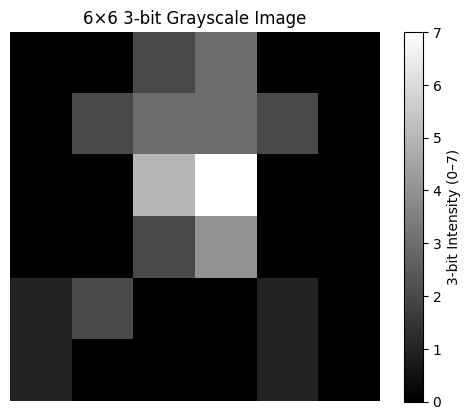

In [30]:
plt.imshow(I, cmap='gray', vmin=0, vmax=7)
plt.colorbar(ticks=range(8), label="3-bit Intensity (0–7)")
plt.title("6×6 3-bit Grayscale Image")
plt.axis('off')
plt.show()

### Q3. HOG Cell Histogram

HOG describes an image by dividing it into small regions and computing histograms of edge directions, capturing local shape information robustly.

#### a : Compute gradients

For a 8x8 grayscale image, I(x,y) = 3x + y. Using centered differences:

$$
G_x = I(x+1,y) - I(x-1,y)
= [3(x+1)+y] - [3(x-1)+y] = 6
$$

$$
G_y = I(x,y+1) - I(x,y-1)
= [3x+(y+1)] - [3x+(y-1)] = 2
$$

So for **every interior pixel**:
$$(G_x, G_y) = (6, 2)$$


#### b : Gradient magnitude and orientation
For every interior pixel,
$$
m_{(x,y)} =  \sqrt{G_x^2 + G_y^2} = \sqrt{6^2 + 2^2} = \sqrt{40} = 2\sqrt{10} ≈ 6.3246
$$
$$
\theta_{(x,y)} = \tan^{-1}(G_y/G_x) = \tan^{-1}(2/6) \approx 18.43^\circ
$$




#### c : Bin interpolation

**Number of contributing pixels**:

The centered difference formula requires neighbours on both sides: I(x+1,y) and I(x-1,y). This makes **boundary pixels (x = 0 and x = 7, y = 0 and y = 7) undefined**, leaving only interior pixels (6x6 = 36).

**Bin interpolation**:

With bin width $\Delta = 20°$, the orientation $\theta \approx 18.43°$ falls between bin $k = 0$(center 0°) and bin $k+1 = 1$ (center 20°) with

$$\alpha = \frac{\theta - \theta_k}{\Delta} = \frac{18.43}{20} \approx 0.9217$$

**Histogram values**:

$$h_0 = 36 \cdot 6.3246 \cdot (1 - 0.9217) \approx 17.82$$

$$h_1 = 36 \cdot 6.3246 \cdot 0.9217 \approx 209.87$$

$$h_2 = h_3 = \cdots = h_8 = 0$$

**Final 9-dimensional HOG histogram**:

$$\boxed{[\ 17.82,\ 209.87,\ 0,\ 0,\ 0,\ 0,\ 0,\ 0,\ 0\ ]}$$

**Interpretation**:

Since I(x,y) = 3x + y is a linear ramp, all interior pixels share an identical gradient direction of $\approx 18.43°$. The entire gradient energy therefore concentrates in the two nearest orientation bins (0° and 20°), heavily dominated by bin 1 (20°).

In [3]:
Gx, Gy = 6, 2
m = np.sqrt(Gx**2 + Gy**2)
theta = np.degrees(np.arctan2(abs(Gy), abs(Gx)))  # unsigned
delta, N = 20.0, 36
k = int(theta / delta)
alpha = (theta - k*delta) / delta
h = np.zeros(9)
h[k]   += m * (1 - alpha) * N
h[k+1] += m * alpha * N
print("HOG histogram:", h)

HOG histogram: [ 17.81685495 209.86713658   0.           0.           0.
   0.           0.           0.           0.        ]


### Q4. CNN Architecture

**Conv layer output size:**
$$
H_{out} = \left\lfloor \frac{H_{in} + 2P - F}{S} \right\rfloor + 1
$$
The output size of Pooling layer is same as above. Pooling layers don't have any learnable parameters.

**Conv parameters (including bias):**
$$
\text{Params} = K \cdot (F \cdot F \cdot C_{in} + 1)
$$
Provided width and height of filters are same.

**Fully connected parameters (including bias):**
$$
\text{Params} = (N_{in} \cdot N_{out}) + N_{out}
$$


#### a : Spatial dimensions after each layer

Input size : $32 \times 32 \times 3$

- Layer 1: Convolution
$$
H_{out} = \frac{32 + 2(1) - 3}{1} + 1 = 32
$$
$$
\text{Output} = 32 \times 32 \times 16
$$
$$
\text{Params} = 16 \cdot (3 \cdot 3 \cdot 3 + 1) = 16 \cdot 28 = 448
$$
-  Layer 2: Max Pooling
$$
H_{out} = \frac{32 - 2}{2} + 1 = 16
$$
$$
\text{Output} = 16 \times 16 \times 16
$$
- Layer 3: Convolution
$$
H_{out} = \frac{16 + 2(1) - 3}{1} + 1 = 16
$$
$$
\text{Output} = 16 \times 16 \times 32
$$
$$
\text{Params} = 32 \cdot (3 \cdot 3 \cdot 16 + 1) = 32 \cdot 145 = 4640
$$
- Layer 4: Max Pooling

$$
H_{out} = \frac{16 - 2}{2} + 1 = 8
$$
$$
\text{Output} = 8 \times 8 \times 32
$$

- Layer 5: Convolution

$$
H_{out} = \frac{8 + 2(1) - 3}{1} + 1 = 8
$$
$$
\text{Output} = 8 \times 8 \times 64
$$
$$
\text{Params} = 64 \cdot (3 \cdot 3 \cdot 32 + 1) = 64 \cdot 289 = 18496
$$

- Layer 6: FC

Feature vector is flattened: $8 \cdot 8 \cdot 64 = 4096$
$$
4096 \rightarrow 128
$$
$$
\text{Params} = (4096 \cdot 128) + 128 = 524288 + 128 = 524416
$$

- Layer 7: FC

$$
128 \rightarrow 10
$$
$$
\text{Params} = (128 \cdot 10) + 10 = 1280 + 10 = 1290
$$


Therefore, output shapes:
$$
  32\times32\times16 \rightarrow 16\times16\times16 \rightarrow 16\times16\times32 \rightarrow 8\times8\times32 \rightarrow 8\times8\times64 \rightarrow 128 \rightarrow 10
$$



#### (b) Flattened size:  
The dimension of the flattened feature vector before the first fully connected layer 4096.

#### (c) Parameters:

Number of learnable parameters (including biases),
- i. The first convolutional layer : 448
- ii. The third convolutional layer : 4640 (assuming it is referring to L3)
- iii. The first fully connected layer : 524416